<a href="https://colab.research.google.com/github/hfelizzola/Curso-Ciencia-de-Datos-con-Python/blob/main/4_machine_learning/9_mineria_texto_nlp.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Minería de Texto y NLP con Python
### Ciencia de Datos con Python
**Ing. Heriberto Felizzola Jiménez**
**Programa de Ingeniería Industrial**

---

Este notebook recorre, paso a paso, las técnicas principales de minería de texto usando dos corpus en español.  
Cada sección conecta directamente con los conceptos de la presentación.

## Sección 0 — Configuración del entorno

Ejecuta esta celda una sola vez antes de comenzar.

In [ ]:
!pip install gensim --quiet
!python -m spacy download es_core_news_sm --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.9/12.9 MB 75.4 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
# Imports

import warnings
warnings.filterwarnings("ignore")   # Suprime advertencias no críticas

# ── Librerías generales ───────────────────────────────────────────────────────
import re                           # Expresiones regulares (limpieza de texto)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm          # Mapas de color para gráficos
import seaborn as sns

# ── NLTK: procesamiento básico de lenguaje natural ────────────────────────────
import nltk
from nltk.tokenize import word_tokenize   # Divide texto en tokens (palabras)
from nltk.corpus import stopwords         # Listas de stop words por idioma
from nltk.stem import SnowballStemmer     # Stemming: reduce palabras a su raíz morfológica

# ── spaCy: lematización y análisis lingüístico ────────────────────────────────
import spacy                        # NLP avanzado; usaremos su lematizador en español

# ── scikit-learn: vectorización de texto ─────────────────────────────────────
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
# CountVectorizer  → Bag of Words: cuenta frecuencia de cada término
# TfidfVectorizer  → TF-IDF: pondera términos por relevancia en el corpus

# ── scikit-learn: entrenamiento y evaluación ──────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline                   # Encadena pasos de preprocesamiento + modelo

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB           # Clasificador: Naive Bayes (referencia)

from sklearn.cluster import KMeans                      # Clustering no supervisado
from sklearn.decomposition import PCA, LatentDirichletAllocation
# PCA                       → Reducción de dimensiones (visualización y preprocesamiento)
# LatentDirichletAllocation → Modelado de tópicos (LDA)

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay
)

from sklearn.manifold import TSNE           # Reducción no lineal a 2D para visualización
from sklearn.preprocessing import LabelEncoder  # Codifica etiquetas de texto a números

# ── WordCloud: visualización de frecuencias ───────────────────────────────────
from wordcloud import WordCloud             # Genera nubes de palabras

# ── Gensim: embeddings de palabras ───────────────────────────────────────────
from gensim.models import Word2Vec          # Entrena vectores densos de palabras (Word2Vec)

# ── Descargas de recursos NLTK ────────────────────────────────────────────────
# punkt / punkt_tab → modelos de tokenización
# stopwords         → listas de palabras vacías por idioma
# vader_lexicon     → diccionario de polaridad para análisis de sentimientos
for pkg in ["punkt", "stopwords", "vader_lexicon", "punkt_tab"]:
    nltk.download(pkg, quiet=True)

# ── Modelo de spaCy en español ────────────────────────────────────────────────
# es_core_news_sm es el modelo pequeño de español; incluye lematizador y POS tagger
# Si no está instalado, ejecuta en terminal: python -m spacy download es_core_news_sm
try:
    nlp = spacy.load("es_core_news_sm")
except:
    print("Instala el modelo con: python -m spacy download es_core_news_sm")

# ── Objetos globales reutilizables ────────────────────────────────────────────
STOP_ES = set(stopwords.words("spanish"))   # Conjunto de stop words en español
stemmer  = SnowballStemmer("spanish")       # Stemmer configurado para español

# ── Estilo global de gráficos ─────────────────────────────────────────────────
plt.rcParams.update({"figure.dpi": 120,         # Resolución de figuras
                     "axes.spines.top": False,   # Oculta borde superior
                     "axes.spines.right": False}) # Oculta borde derecho

print("✓ Entorno listo")

✓ Entorno listo


## Sección 1 — Los Corpus de Trabajo

Trabajaremos con dos corpus en español definidos directamente en el notebook.

| Corpus | Contenido | Uso principal |
|--------|-----------|---------------|
| **A — Reseñas de e-commerce** | 36 reseñas con etiqueta de polaridad | Sentimientos, analítica descriptiva |
| **B — Noticias temáticas** | 40 noticias de 4 categorías | Clustering, LDA, clasificación |

In [ ]:
# ── Corpus A: Reseñas de e-commerce ──────────────────────────────────────────
resenas = [
    # Positivas
    {"texto": "Excelente producto, llegó rápido y bien empacado. Totalmente recomendado.",        "polaridad": "positivo"},
    {"texto": "La calidad es increíble para el precio. Muy satisfecho con la compra.",             "polaridad": "positivo"},
    {"texto": "Superó mis expectativas. El material es resistente y el diseño muy elegante.",      "polaridad": "positivo"},
    {"texto": "Envío rapidísimo, el producto es exactamente como en las fotos. Perfecto.",         "polaridad": "positivo"},
    {"texto": "Muy buena atención al cliente, resolvieron mi duda en minutos. Excelente servicio.","polaridad": "positivo"},
    {"texto": "El producto funciona perfectamente. Lo recomiendo ampliamente.",                    "polaridad": "positivo"},
    {"texto": "Llegó antes de lo esperado y en perfectas condiciones. Muy contento.",              "polaridad": "positivo"},
    {"texto": "Buena relación calidad-precio. El producto es duradero y práctico.",               "polaridad": "positivo"},
    {"texto": "Me encantó, es exactamente lo que buscaba. Muy buena compra.",                     "polaridad": "positivo"},
    {"texto": "El servicio fue impecable y el producto es de excelente calidad.",                 "polaridad": "positivo"},
    {"texto": "Rápida entrega y producto en óptimas condiciones. Volveré a comprar.",             "polaridad": "positivo"},
    {"texto": "Producto de primera calidad, supera lo que esperaba. Muy recomendable.",           "polaridad": "positivo"},
    # Negativas
    {"texto": "Pésima calidad, el producto se rompió al segundo día de uso.",                     "polaridad": "negativo"},
    {"texto": "El envío tardó tres semanas y llegó dañado. Muy mala experiencia.",                "polaridad": "negativo"},
    {"texto": "No funciona como dice la descripción. Completamente decepcionante.",               "polaridad": "negativo"},
    {"texto": "Horrible atención al cliente, no responden los mensajes. Jamás volvería a comprar.","polaridad": "negativo"},
    {"texto": "El producto huele raro y el material es muy frágil. No lo recomiendo.",            "polaridad": "negativo"},
    {"texto": "Me cobraron de más y el servicio al cliente fue grosero. Muy malo.",               "polaridad": "negativo"},
    {"texto": "Llegó incompleto y sin manual. La calidad es muy inferior a la foto.",             "polaridad": "negativo"},
    {"texto": "Se dañó al primer uso. Completamente inútil y una pérdida de dinero.",             "polaridad": "negativo"},
    {"texto": "La entrega fue un desastre, perdieron el paquete y tardaron en responder.",        "polaridad": "negativo"},
    {"texto": "El producto no corresponde a la descripción. Muy decepcionado con la compra.",     "polaridad": "negativo"},
    {"texto": "Mala calidad, el color es diferente y el tamaño no coincide con lo anunciado.",    "polaridad": "negativo"},
    {"texto": "Servicio deplorable. El vendedor no cumplió con los tiempos prometidos.",          "polaridad": "negativo"},
    # Neutras
    {"texto": "El producto llegó en el tiempo estimado. Cumple con lo básico.",                   "polaridad": "neutro"},
    {"texto": "Nada especial, es lo que se describe. Sirve para lo que se necesita.",             "polaridad": "neutro"},
    {"texto": "El empaque estaba en buen estado. El producto es funcional.",                      "polaridad": "neutro"},
    {"texto": "Es un producto estándar. No es ni bueno ni malo, simplemente cumple su función.",  "polaridad": "neutro"},
    {"texto": "La entrega fue normal, sin problemas ni sorpresas.",                               "polaridad": "neutro"},
    {"texto": "El artículo es tal como se muestra. Ni más ni menos.",                            "polaridad": "neutro"},
    {"texto": "Producto básico que hace lo que promete. Aceptable para el precio.",              "polaridad": "neutro"},
    {"texto": "Funciona bien aunque sin nada destacable. Es una opción regular.",                "polaridad": "neutro"},
    {"texto": "La calidad es promedio. Podría ser mejor pero tampoco es malo.",                  "polaridad": "neutro"},
    {"texto": "Llegó en el plazo indicado. El producto es correcto aunque sin sorpresas.",       "polaridad": "neutro"},
    {"texto": "El producto es aceptable, aunque esperaba algo de mejor calidad.",                "polaridad": "neutro"},
    {"texto": "Compra sin problemas. El artículo funciona aunque es bastante simple.",           "polaridad": "neutro"},
]

df_resenas = pd.DataFrame(resenas)
print("Corpus A — Reseñas:")
print(df_resenas["polaridad"].value_counts().to_string())
print(f"Total: {len(df_resenas)} documentos")

Corpus A — Reseñas:
polaridad
positivo    12
negativo    12
neutro      12
Total: 36 documentos


In [ ]:
# ── Corpus B: Noticias temáticas ─────────────────────────────────────────────
noticias = [
    # Tecnología
    {"texto": "La inteligencia artificial revoluciona el diagnóstico médico con nuevos algoritmos de aprendizaje profundo.",                       "categoria": "tecnologia"},
    {"texto": "Apple lanzó su nuevo chip diseñado para acelerar modelos de machine learning en dispositivos móviles.",                             "categoria": "tecnologia"},
    {"texto": "Los modelos de lenguaje como GPT transforman la forma en que las empresas procesan grandes volúmenes de datos.",                   "categoria": "tecnologia"},
    {"texto": "Python sigue siendo el lenguaje más usado en ciencia de datos según la encuesta anual de desarrolladores.",                        "categoria": "tecnologia"},
    {"texto": "Google presenta una nueva arquitectura de redes neuronales para procesamiento de lenguaje natural.",                                "categoria": "tecnologia"},
    {"texto": "El uso de computación en la nube crece un 40% en empresas latinoamericanas durante el último trimestre.",                          "categoria": "tecnologia"},
    {"texto": "Investigadores desarrollan un algoritmo capaz de detectar fraudes bancarios en tiempo real con alta precisión.",                    "categoria": "tecnologia"},
    {"texto": "La robótica colaborativa avanza con nuevos sensores que permiten trabajar junto a humanos con mayor seguridad.",                    "categoria": "tecnologia"},
    {"texto": "Meta anuncia nuevas herramientas de análisis de texto para sus plataformas de redes sociales.",                                     "categoria": "tecnologia"},
    {"texto": "El mercado de software de automatización crece impulsado por la demanda de soluciones de inteligencia artificial.",                 "categoria": "tecnologia"},
    # Deportes
    {"texto": "La selección nacional de fútbol venció tres a uno al equipo visitante en un emocionante partido de clasificación.",                "categoria": "deportes"},
    {"texto": "El tenista número uno del mundo avanzó a la final tras derrotar a su rival en tres sets.",                                         "categoria": "deportes"},
    {"texto": "El equipo local ganó el campeonato después de superar en penaltis al campeón defensor.",                                           "categoria": "deportes"},
    {"texto": "El ciclista colombiano lidera la clasificación general tras la etapa de montaña más exigente del tour.",                           "categoria": "deportes"},
    {"texto": "El entrenador presentó su renuncia luego de la derrota que dejó al equipo en el último lugar de la tabla.",                        "categoria": "deportes"},
    {"texto": "Las olimpiadas registraron una cifra récord de participantes con más de diez mil atletas de todo el mundo.",                       "categoria": "deportes"},
    {"texto": "El boxeador nacional retuvo su título mundial tras noquear a su oponente en el sexto asalto.",                                     "categoria": "deportes"},
    {"texto": "La liga de baloncesto arrancó con partidos llenos de emoción y canastas de último segundo.",                                       "categoria": "deportes"},
    {"texto": "El corredor rompe el récord mundial de los cien metros planos en el campeonato internacional de atletismo.",                       "categoria": "deportes"},
    {"texto": "El club anuncia la contratación de tres jugadores internacionales para reforzar su plantilla esta temporada.",                     "categoria": "deportes"},
    # Salud
    {"texto": "Un nuevo estudio revela que el ejercicio diario reduce significativamente el riesgo de enfermedades cardiovasculares.",             "categoria": "salud"},
    {"texto": "La OMS aprobó una nueva vacuna contra la malaria que muestra eficacia superior al setenta por ciento en ensayos clínicos.",       "categoria": "salud"},
    {"texto": "Investigadores descubren un biomarcador que permite detectar el Alzheimer diez años antes de los primeros síntomas.",              "categoria": "salud"},
    {"texto": "La telemedicina crece en Latinoamérica y permite a pacientes rurales acceder a especialistas médicos.",                            "categoria": "salud"},
    {"texto": "Un equipo médico realiza con éxito el primer trasplante de riñón asistido por robots en Colombia.",                               "categoria": "salud"},
    {"texto": "El consumo excesivo de azúcar está relacionado con el aumento de casos de diabetes tipo dos en jóvenes.",                         "categoria": "salud"},
    {"texto": "Un nuevo fármaco para el tratamiento del cáncer de pulmón muestra resultados prometedores en fase tres.",                         "categoria": "salud"},
    {"texto": "Los especialistas advierten sobre el aumento de casos de depresión y ansiedad en adolescentes tras la pandemia.",                  "categoria": "salud"},
    {"texto": "La dieta mediterránea reduce el riesgo de enfermedades crónicas según un estudio con más de veinte mil pacientes.",               "categoria": "salud"},
    {"texto": "Científicos desarrollan una prueba de diagnóstico rápido para detectar enfermedades infecciosas en minutos.",                     "categoria": "salud"},
    # Economía
    {"texto": "El banco central subió las tasas de interés para controlar la inflación que alcanzó niveles históricos.",                         "categoria": "economia"},
    {"texto": "Las exportaciones de café crecieron un doce por ciento impulsadas por la demanda internacional y los altos precios.",             "categoria": "economia"},
    {"texto": "La bolsa de valores cerró en alza luego del anuncio de nuevas inversiones extranjeras en el sector energético.",                   "categoria": "economia"},
    {"texto": "El desempleo bajó al cinco por ciento gracias al crecimiento del sector servicios y la recuperación del comercio.",               "categoria": "economia"},
    {"texto": "El gobierno anunció un paquete de estímulos fiscales para reactivar la economía y apoyar a las pequeñas empresas.",               "categoria": "economia"},
    {"texto": "La deuda pública llegó a niveles récord presionada por el gasto social y la caída de los ingresos tributarios.",                  "categoria": "economia"},
    {"texto": "El precio del petróleo superó los noventa dólares impactando los costos de producción en toda la cadena industrial.",             "categoria": "economia"},
    {"texto": "Las remesas enviadas por migrantes representan ya el quince por ciento del producto interno bruto nacional.",                     "categoria": "economia"},
    {"texto": "El sector de construcción lidera el crecimiento económico con un aumento del ocho por ciento en el último trimestre.",            "categoria": "economia"},
    {"texto": "La inflación afecta el poder adquisitivo de los hogares que recortan gastos en alimentación y transporte.",                       "categoria": "economia"},
]

df_noticias = pd.DataFrame(noticias)
print("Corpus B — Noticias:")
print(df_noticias["categoria"].value_counts().to_string())
print(f"Total: {len(df_noticias)} documentos")

Corpus B — Noticias:
categoria
tecnologia    10
deportes      10
salud         10
economia      10
Total: 40 documentos


## Sección 2 — Preprocesamiento de Texto

Transformamos el texto crudo en una secuencia de tokens limpios y normalizados.  
Aplicamos cada paso de forma individual para ver su efecto, y al final construimos un pipeline reutilizable.

In [ ]:
texto_ejemplo = df_resenas.loc[0, "texto"]
print("Original:", texto_ejemplo)

# Paso 1: minúsculas
p1 = texto_ejemplo.lower()
print("\n1. Minúsculas:", p1)

# Paso 2: eliminar caracteres especiales
p2 = re.sub(r"[^a-záéíóúüñ\s]", "", p1)
print("\n2. Sin caracteres especiales:", p2)

# Paso 3: tokenización
p3 = word_tokenize(p2, language="spanish")
print("\n3. Tokens:", p3)

# Paso 4: eliminar stop words
p4 = [t for t in p3 if t not in STOP_ES]
print("\n4. Sin stop words:", p4)

# Paso 5: stemming
p5 = [stemmer.stem(t) for t in p4]
print("\n5. Stemming:", p5)

# Paso 6: lematización con spaCy
doc = nlp(" ".join(p4))
p6 = [token.lemma_ for token in doc]
print("\n6. Lematización:", p6)

Original: Excelente producto, llegó rápido y bien empacado. Totalmente recomendado.

1. Minúsculas: excelente producto, llegó rápido y bien empacado. totalmente recomendado.

2. Sin caracteres especiales: excelente producto llegó rápido y bien empacado totalmente recomendado

3. Tokens: ['excelente', 'producto', 'llegó', 'rápido', 'y', 'bien', 'empacado', 'totalmente', 'recomendado']

4. Sin stop words: ['excelente', 'producto', 'llegó', 'rápido', 'bien', 'empacado', 'totalmente', 'recomendado']

5. Stemming: ['excelent', 'product', 'lleg', 'rap', 'bien', 'empac', 'total', 'recomend']

6. Lematización: ['excelente', 'producto', 'llegar', 'rápido', 'bien', 'empacado', 'totalmente', 'recomendado']


### Tabla comparativa antes → después

In [ ]:
comparacion = pd.DataFrame({
    "Paso": ["Original", "Minúsculas", "Sin especiales",
             "Tokens", "Sin stop words", "Stemming", "Lematización"],
    "Resultado": [texto_ejemplo, p1, p2,
                  " | ".join(p3), " | ".join(p4),
                  " | ".join(p5), " | ".join(p6)]
})
comparacion

,Paso,Resultado
0,Original,"Excelente producto, llegó rápido y bien empaca..."
1,Minúsculas,"excelente producto, llegó rápido y bien empaca..."
2,Sin especiales,excelente producto llegó rápido y bien empacad...
3,Tokens,excelente | producto | llegó | rápido | y | bi...
4,Sin stop words,excelente | producto | llegó | rápido | bien |...
5,Stemming,excelent | product | lleg | rap | bien | empac...
6,Lematización,excelente | producto | llegar | rápido | bien ...


### Función pipeline completa

Esta función se usará en todas las secciones siguientes.

In [ ]:
def preprocesar(texto, metodo="lema"):
    texto = texto.lower()
    texto = re.sub(r"[^a-záéíóúüñ\s]", "", texto)
    tokens = word_tokenize(texto, language="spanish")
    tokens = [t for t in tokens if t not in STOP_ES and len(t) > 2]
    if metodo == "stem":
        tokens = [stemmer.stem(t) for t in tokens]
    elif metodo == "lema":
        doc = nlp(" ".join(tokens))
        tokens = [token.lemma_ for token in doc]
    return " ".join(tokens)

# Aplicar al Corpus A
df_resenas["texto_limpio"] = df_resenas["texto"].apply(preprocesar)

# Verificar resultado
df_resenas[["texto", "texto_limpio"]].head(4)

,texto,texto_limpio
0,"Excelente producto, llegó rápido y bien empaca...",excelente producto llegar rápido bien empacado...
1,La calidad es increíble para el precio. Muy sa...,calidad increíble precio satisfecho compra
2,Superó mis expectativas. El material es resist...,superar expectativa material resistente diseño...
3,"Envío rapidísimo, el producto es exactamente c...",envío rapidísimo producto exactamente foto per...


## Sección 3 — Representación Vectorial

Convertimos los textos en vectores numéricos para que los algoritmos de ML puedan procesarlos.  
Usamos el Corpus B (noticias) y comparamos dos enfoques: **Bag of Words** y **TF-IDF**.

In [ ]:
df_noticias["texto_limpio"] = df_noticias["texto"].apply(preprocesar)

n_features = 50 # Configurar para establecer un máximo de palabras en la bolsa

# Bag of Words
bow = CountVectorizer(max_features=n_features)
X_bow = bow.fit_transform(df_noticias["texto_limpio"])

df_bow = pd.DataFrame(X_bow.toarray(), columns=bow.get_feature_names_out())
print("Matriz BoW  —  filas: documentos | columnas: términos")
print(df_bow.shape)
df_bow.head(10)

Matriz BoW  —  filas: documentos | columnas: términos
(40, 50)


,anunciar,artificial,aumento,campeonato,caso,ciento,clasificación,crecer,desarrollar,detectar,...,reducir,riesgo,récord,sector,según,social,superar,tras,tres,último
0,0,1,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,1
6,0,0,0,0,0,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
9,0,1,0,0,0,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0


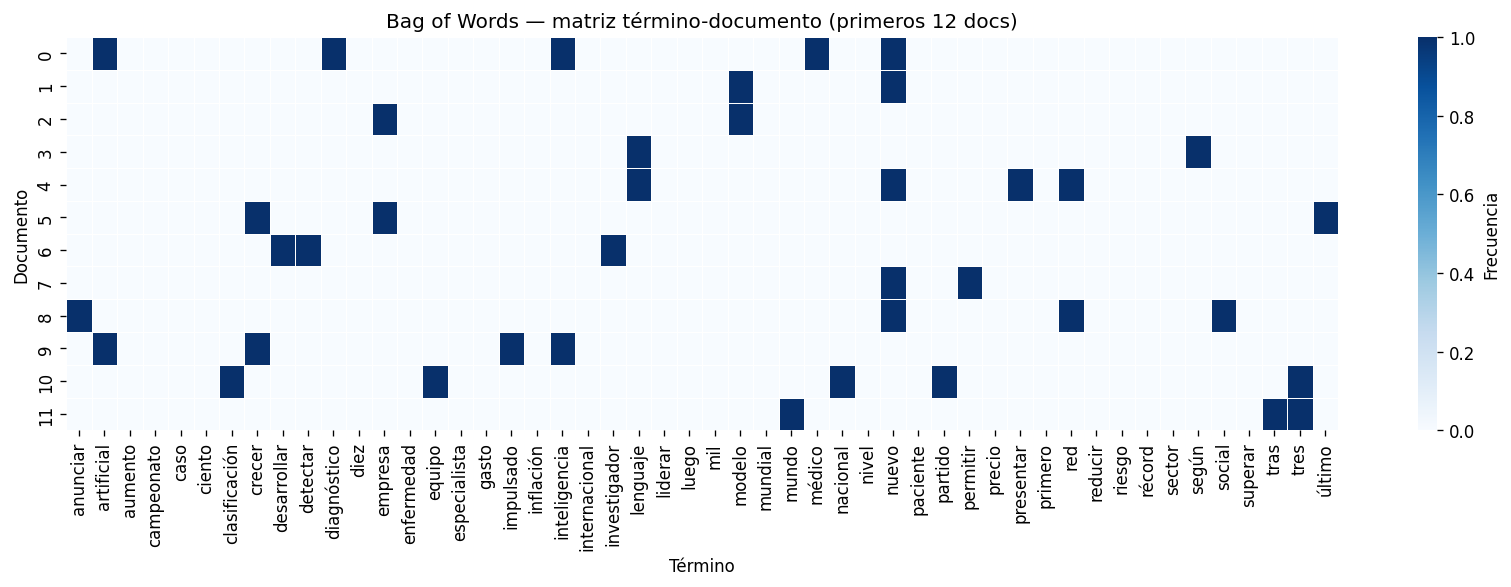

In [ ]:
# Heatmap de la matriz BoW (primeros 12 documentos, 20 términos)
fig, ax = plt.subplots(figsize=(14, 5))
sns.heatmap(df_bow.iloc[:12], cmap="Blues", linewidths=0.3,
            cbar_kws={"label": "Frecuencia"}, ax=ax)
ax.set_xlabel("Término")
ax.set_ylabel("Documento")
ax.set_title("Bag of Words — matriz término-documento (primeros 12 docs)")
plt.tight_layout()
plt.show()

In [ ]:
# TF-IDF
tfidf = TfidfVectorizer(max_features=n_features)
X_tfidf = tfidf.fit_transform(df_noticias["texto_limpio"])

df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=tfidf.get_feature_names_out())

# Comparación: top 5 términos por peso en el primer documento
terminos = tfidf.get_feature_names_out()
pesos = X_tfidf.toarray()[0]
top5 = pd.DataFrame({"término": terminos, "TF-IDF": pesos}).sort_values("TF-IDF", ascending=False).head(5)
print("Top 5 términos más relevantes — Documento 0:")
print(top5.to_string(index=False))

Top 5 términos más relevantes — Documento 0:
     término   TF-IDF
  artificial 0.482693
 diagnóstico 0.482693
inteligencia 0.482693
      médico 0.444279
       nuevo 0.321930


In [ ]:
# Comparación BoW vs TF-IDF para un mismo documento
doc_idx = 0
df_comp = pd.DataFrame({
    "término": bow.get_feature_names_out(),
    "BoW (frecuencia)": X_bow.toarray()[doc_idx],
    "TF-IDF (peso)":    X_tfidf.toarray()[doc_idx]
}).query("`BoW (frecuencia)` > 0").sort_values("TF-IDF (peso)", ascending=False)

print(f"Documento {doc_idx}: '{df_noticias['texto'].iloc[doc_idx][:n_features]}...'\n")
print(df_comp.to_string(index=False))

Documento 0: 'La inteligencia artificial revoluciona el diagnóst...'

     término  BoW (frecuencia)  TF-IDF (peso)
  artificial                 1       0.482693
 diagnóstico                 1       0.482693
inteligencia                 1       0.482693
      médico                 1       0.444279
       nuevo                 1       0.321930


## Sección 4 — Analítica Descriptiva

Exploramos el contenido del Corpus A (reseñas) antes de aplicar modelos.

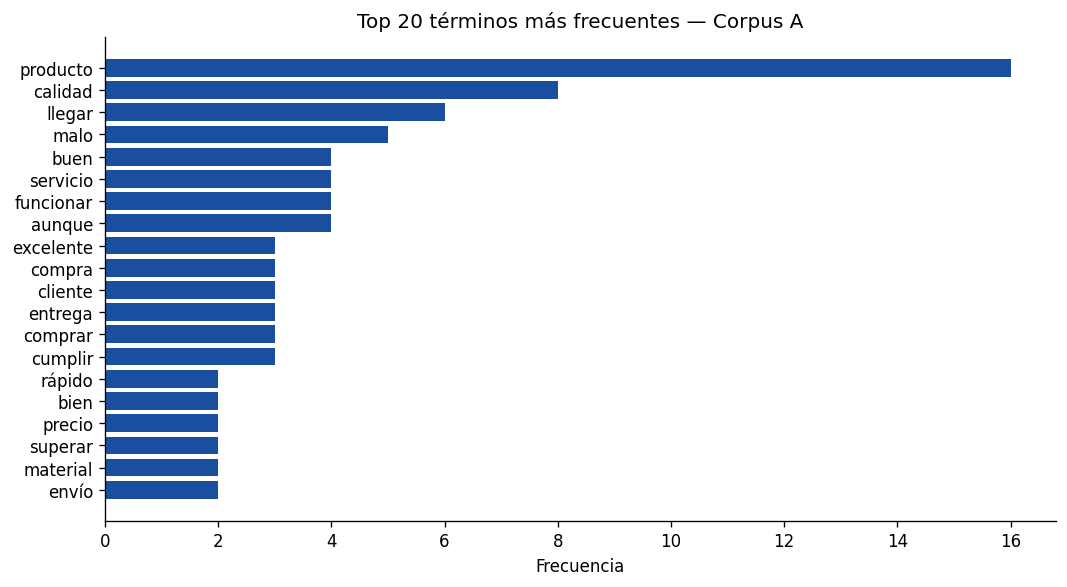

In [ ]:
from collections import Counter

todos_tokens = " ".join(df_resenas["texto_limpio"]).split()
frecuencias = Counter(todos_tokens)
top20 = pd.DataFrame(frecuencias.most_common(20), columns=["término", "frecuencia"])

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top20["término"][::-1], top20["frecuencia"][::-1], color="#1A4FA0")
ax.set_xlabel("Frecuencia")
ax.set_title("Top 20 términos más frecuentes — Corpus A")
plt.tight_layout()
plt.show()

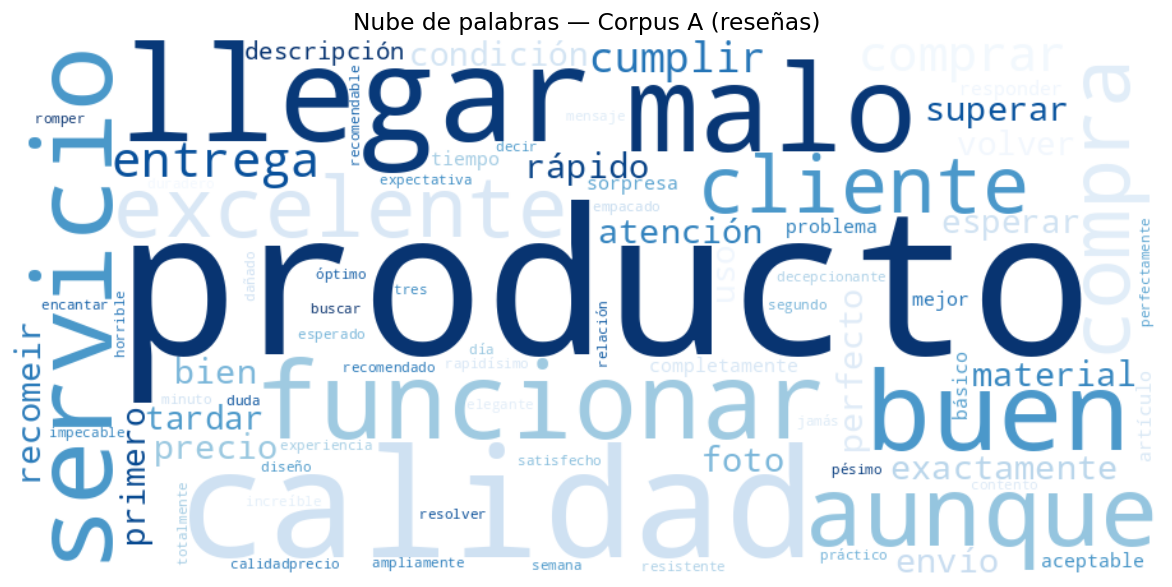

In [ ]:
# Nube de palabras general
texto_union = " ".join(df_resenas["texto_limpio"])
wc = WordCloud(width=900, height=420, background_color="white",
               colormap="Blues", max_words=80).generate(texto_union)

fig, ax = plt.subplots(figsize=(11, 5))
ax.imshow(wc, interpolation="bilinear")
ax.axis("off")
ax.set_title("Nube de palabras — Corpus A (reseñas)", fontsize=14)
plt.tight_layout()
plt.show()

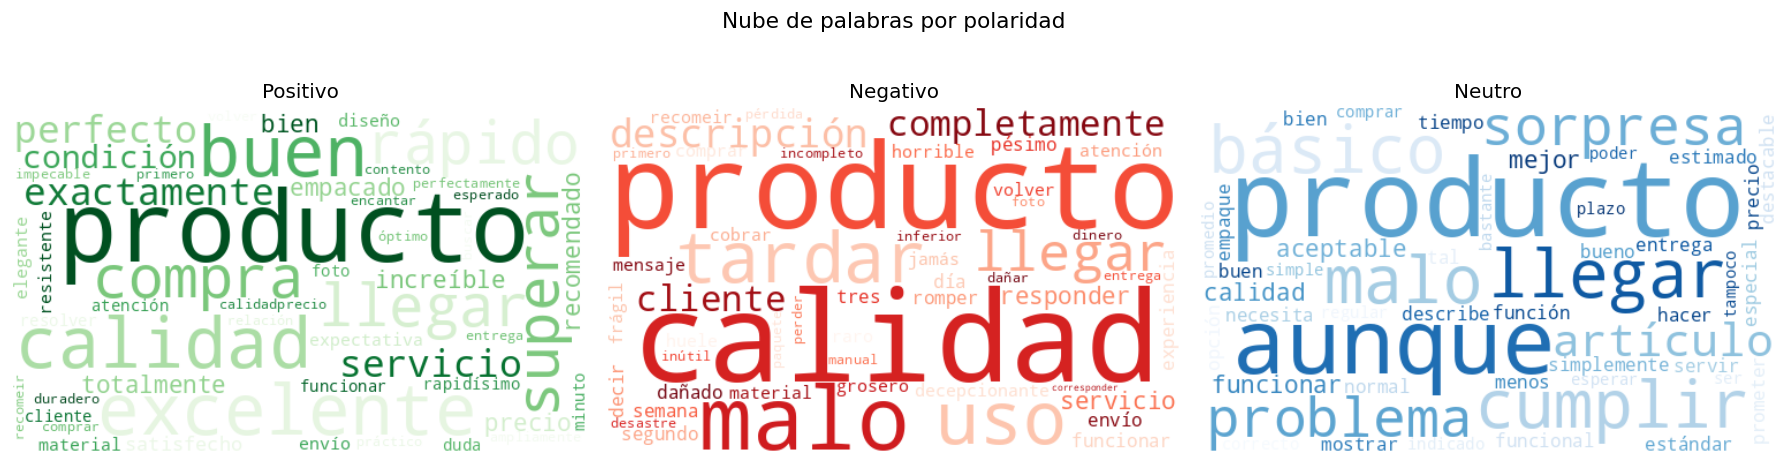

In [ ]:
# Nube de palabras por polaridad
polaridades = ["positivo", "negativo", "neutro"]
colores      = ["Greens",  "Reds",     "Blues"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, pol, cmap in zip(axes, polaridades, colores):
    textos = " ".join(df_resenas[df_resenas["polaridad"] == pol]["texto_limpio"])
    wc = WordCloud(width=500, height=300, background_color="white",
                   colormap=cmap, max_words=50).generate(textos)
    ax.imshow(wc, interpolation="bilinear")
    ax.axis("off")
    ax.set_title(pol.capitalize(), fontsize=12)
plt.suptitle("Nube de palabras por polaridad", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

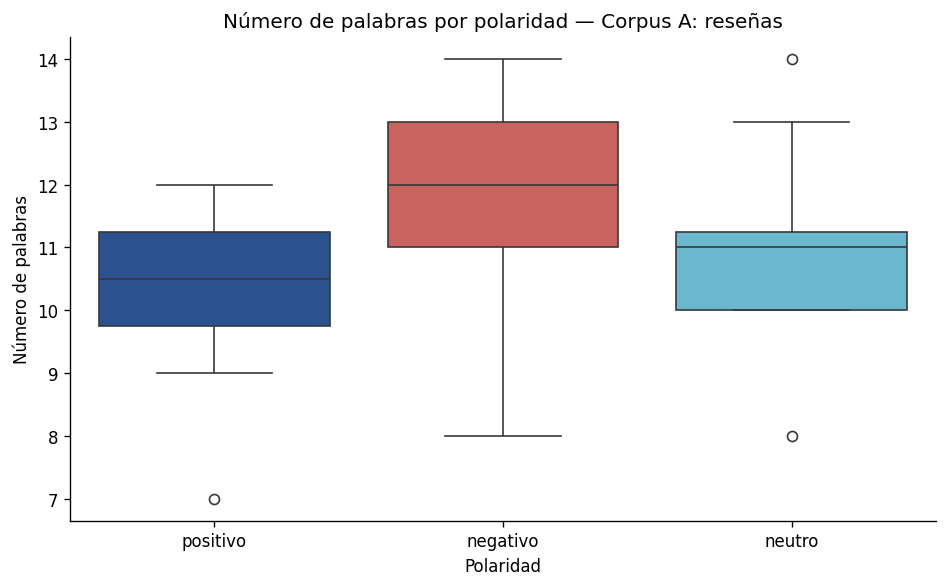

In [ ]:
# Boxplot del numero de palabras segun la polaridad
plt.figure(figsize=(8, 5))
sns.boxplot(x="polaridad", y="n_palabras", data=df_resenas, palette=["#1A4FA0", "#D9534F", "#5BC0DE"])
plt.xlabel("Polaridad")
plt.ylabel("Número de palabras")
plt.title("Número de palabras por polaridad — Corpus A: reseñas")
plt.tight_layout()
plt.show()

## Sección 5 — Análisis de Sentimientos

Comparamos dos enfoques:
1. **VADER** — basado en léxico, no requiere entrenamiento
2. **Modelos supervisados** — Regresión Logística, Árbol de Decisión y Random Forest

### 5.1 — VADER (enfoque léxico)

In [ ]:
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def clasificar_vader(texto):
    score = sia.polarity_scores(texto)["compound"]
    if score >= 0.05:
        return "positivo"
    elif score <= -0.05:
        return "negativo"
    else:
        return "neutro"

df_resenas["vader"] = df_resenas["texto"].apply(clasificar_vader)

# Resultados en muestra
df_resenas[["texto", "polaridad", "vader"]].head(8)

,texto,polaridad,vader
0,"Excelente producto, llegó rápido y bien empaca...",positivo,neutro
1,La calidad es increíble para el precio. Muy sa...,positivo,neutro
2,Superó mis expectativas. El material es resist...,positivo,neutro
3,"Envío rapidísimo, el producto es exactamente c...",positivo,positivo
4,"Muy buena atención al cliente, resolvieron mi ...",positivo,neutro
5,El producto funciona perfectamente. Lo recomie...,positivo,neutro
6,Llegó antes de lo esperado y en perfectas cond...,positivo,positivo
7,Buena relación calidad-precio. El producto es ...,positivo,neutro


In [ ]:
# Precisión de VADER sobre el corpus
acc_vader = accuracy_score(df_resenas["polaridad"], df_resenas["vader"])
print(f"Accuracy VADER: {acc_vader:.2f}\n")
print(classification_report(df_resenas["polaridad"], df_resenas["vader"]))

Accuracy VADER: 0.44

              precision    recall  f1-score   support

    negativo       0.58      0.58      0.58        12
      neutro       0.32      0.58      0.41        12
    positivo       1.00      0.17      0.29        12

    accuracy                           0.44        36
   macro avg       0.63      0.44      0.43        36
weighted avg       0.63      0.44      0.43        36



**Nota:** VADER fue diseñado para inglés y redes sociales.  
Su desempeño en español es limitado — es útil como línea base rápida pero los modelos supervisados lo superan cuando se dispone de datos etiquetados.

### 5.2 — Modelos supervisados

In [ ]:
X = df_resenas["texto_limpio"]
y = df_resenas["polaridad"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y)

modelos = {
    "Regresión Logística": Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf",   LogisticRegression(max_iter=1000))
    ]),
    "Árbol de Decisión": Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf",   DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf",   RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
}

resultados = []
for nombre, pipe in modelos.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    resultados.append({
        "Modelo":    nombre,
        "Accuracy":  round(accuracy_score(y_test, y_pred), 3),
        "F1 (macro)":round(f1_score(y_test, y_pred, average="macro"), 3),
    })

df_resultados = pd.DataFrame(resultados)
print("Comparación de modelos — Análisis de Sentimientos")
print(df_resultados.to_string(index=False))

Comparación de modelos — Análisis de Sentimientos
             Modelo  Accuracy  F1 (macro)
Regresión Logística     0.444       0.451
  Árbol de Decisión     0.111       0.074
      Random Forest     0.556       0.517


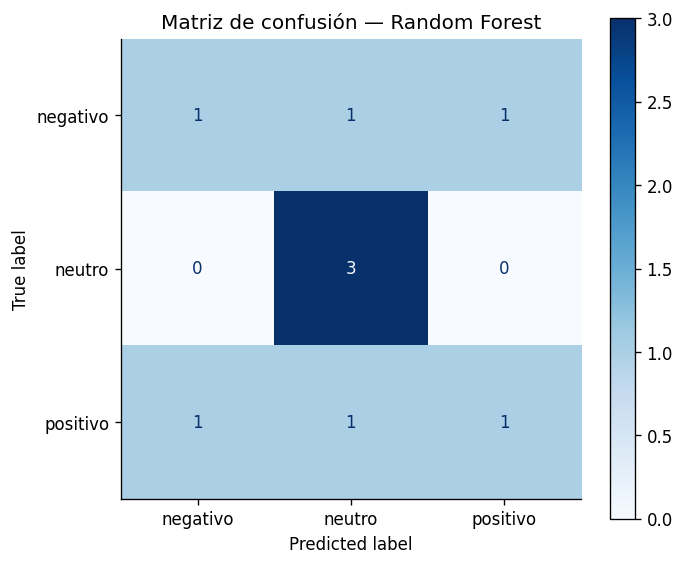

In [ ]:
# Matriz de confusión del mejor modelo
mejor = df_resultados.loc[df_resultados["Accuracy"].idxmax(), "Modelo"]
y_pred_mejor = modelos[mejor].predict(X_test)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_mejor,
    display_labels=["negativo", "neutro", "positivo"],
    cmap="Blues", ax=ax)
ax.set_title(f"Matriz de confusión — {mejor}")
plt.tight_layout()
plt.show()

In [ ]:
# Predicción sobre textos nuevos
nuevas_resenas = [
    "El producto es fantástico, superó todas mis expectativas.",
    "Llegó roto y el vendedor no da respuesta. Terrible.",
    "Es un artículo normal, cumple su función básica."
]

pipe_mejor = modelos[mejor]
predicciones = pipe_mejor.predict(nuevas_resenas)

for texto, pred in zip(nuevas_resenas, predicciones):
    print(f"[{pred.upper():>9}]  {texto}")

[   NEUTRO]  El producto es fantástico, superó todas mis expectativas.
[ NEGATIVO]  Llegó roto y el vendedor no da respuesta. Terrible.
[   NEUTRO]  Es un artículo normal, cumple su función básica.


## Sección 6 — Modelado de Tópicos (LDA)

LDA descubre temas latentes en el corpus de forma no supervisada.  
Aplicamos el modelo sobre el Corpus B (noticias) y verificamos si los tópicos encontrados coinciden con las categorías reales.

In [ ]:
# Vectorizamos con BoW (LDA trabaja con conteos, no con TF-IDF)
bow_lda = CountVectorizer(max_features=500, min_df=2)
X_lda = bow_lda.fit_transform(df_noticias["texto_limpio"])

# Entrenamos LDA con K=4 tópicos (sabemos que hay 4 categorías)
lda = LatentDirichletAllocation(n_components=4, random_state=42,
                                 max_iter=50, learning_method="batch")
lda.fit(X_lda)
print("✓ LDA entrenado")

✓ LDA entrenado


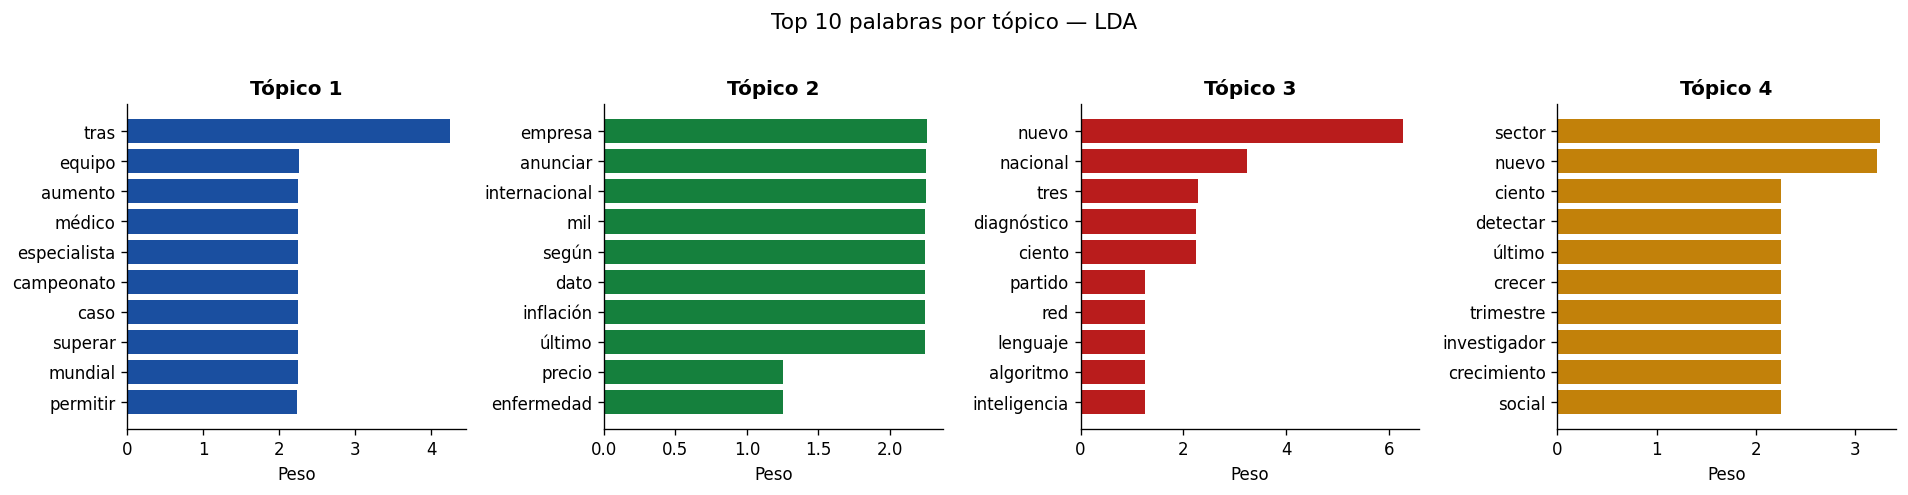

In [ ]:
# Top 10 palabras por tópico
vocab = bow_lda.get_feature_names_out()
nombres_topicos = ["Tópico 1", "Tópico 2", "Tópico 3", "Tópico 4"]
colores_topicos = ["#1A4FA0", "#15803D", "#B91C1C", "#C2810A"]

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for i, (ax, nombre, color) in enumerate(zip(axes, nombres_topicos, colores_topicos)):
    indices = lda.components_[i].argsort()[-10:][::-1]
    palabras = [vocab[j] for j in indices]
    pesos    = lda.components_[i][indices]
    ax.barh(palabras[::-1], pesos[::-1], color=color)
    ax.set_title(nombre, fontsize=12, fontweight="bold")
    ax.set_xlabel("Peso")
plt.suptitle("Top 10 palabras por tópico — LDA", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Asignar tópico dominante a cada documento
doc_topicos = lda.transform(X_lda)
df_noticias["topico_lda"] = doc_topicos.argmax(axis=1)

# Distribución de tópicos vs categorías reales
tabla = pd.crosstab(df_noticias["categoria"], df_noticias["topico_lda"],
                    rownames=["Categoría real"], colnames=["Tópico LDA"])
print("¿Coinciden los tópicos con las categorías reales?")
print(tabla)

¿Coinciden los tópicos con las categorías reales?
Tópico LDA      0  1  2  3
Categoría real            
deportes        5  4  1  0
economia        1  4  1  4
salud           4  1  3  2
tecnologia      0  2  4  4


**Interpretación:** cada fila es una categoría real y cada columna es un tópico descubierto por LDA.  
Si el modelo captura bien la estructura del corpus, deberíamos ver que cada categoría domina un tópico distinto.

## Sección 7 — Clustering de Documentos con K-Means y PCA

Aplicamos K-Means sobre vectores TF-IDF para agrupar documentos sin usar las etiquetas.  
PCA cumple dos roles en esta sección:
1. **Reducción para K-Means:** bajar la dimensionalidad mejora el clustering en espacios de texto dispersos
2. **Visualización:** reducir a 2 componentes para graficar los clusters

In [ ]:
# Vectorización completa
tfidf_km = TfidfVectorizer(max_features=200)
X_km = tfidf_km.fit_transform(df_noticias["texto_limpio"]).toarray()
print(f"Dimensión original: {X_km.shape}")

# PCA para reducir antes de K-Means
pca_km = PCA(n_components=30, random_state=42)
X_pca  = pca_km.fit_transform(X_km)
print(f"Dimensión tras PCA: {X_pca.shape}")
print(f"Varianza explicada: {pca_km.explained_variance_ratio_.sum():.1%}")

Dimensión original: (40, 200)
Dimensión tras PCA: (40, 30)
Varianza explicada: 85.9%


In [ ]:
# K-Means con K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_noticias["cluster"] = kmeans.fit_predict(X_pca)

# Comparación clusters vs categorías reales
tabla_km = pd.crosstab(df_noticias["categoria"], df_noticias["cluster"],
                        rownames=["Categoría real"], colnames=["Cluster K-Means"])
print(tabla_km)

Cluster K-Means  0  1  2  3
Categoría real             
deportes         3  7  0  0
economia         1  4  2  3
salud            2  6  1  1
tecnologia       1  5  4  0


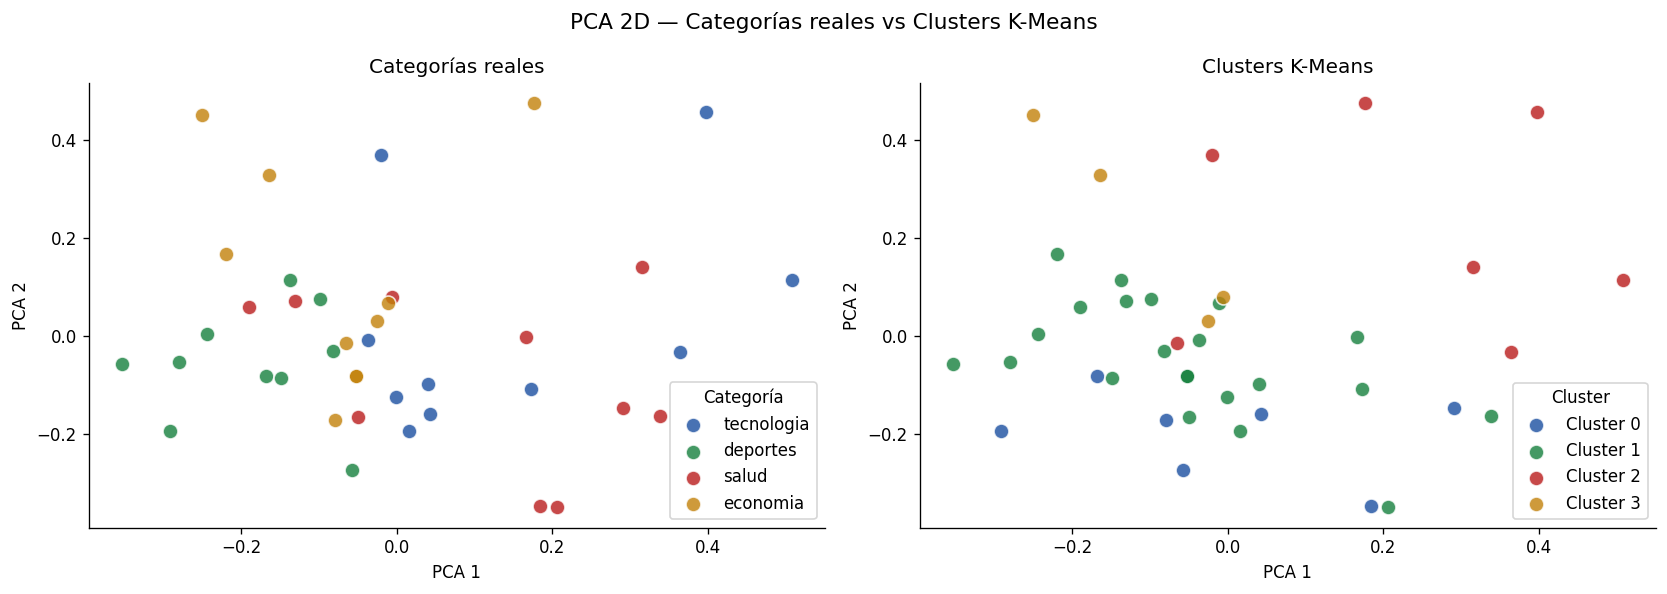

In [ ]:
# Visualización en 2D con PCA
pca_2d = PCA(n_components=2, random_state=42)
X_2d   = pca_2d.fit_transform(X_km)

categorias = df_noticias["categoria"].unique()
colores_cat = {"tecnologia": "#1A4FA0", "deportes": "#15803D",
               "salud":      "#B91C1C", "economia": "#C2810A"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: color = categoría real
for cat, color in colores_cat.items():
    mask = df_noticias["categoria"] == cat
    axes[0].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, label=cat, s=80, alpha=0.8, edgecolors="white")
axes[0].set_title("Categorías reales")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
axes[0].legend(title="Categoría")

# Gráfico 2: color = cluster K-Means
colores_km = {0: "#1A4FA0", 1: "#15803D", 2: "#B91C1C", 3: "#C2810A"}
for cl, color in colores_km.items():
    mask = df_noticias["cluster"] == cl
    axes[1].scatter(X_2d[mask, 0], X_2d[mask, 1],
                    c=color, label=f"Cluster {cl}", s=80, alpha=0.8, edgecolors="white")
axes[1].set_title("Clusters K-Means")
axes[1].set_xlabel("PCA 1")
axes[1].set_ylabel("PCA 2")
axes[1].legend(title="Cluster")

plt.suptitle("PCA 2D — Categorías reales vs Clusters K-Means", fontsize=13)
plt.tight_layout()
plt.show()

## Sección 8 — Clasificación de Documentos

Clasificamos las noticias del Corpus B en sus 4 categorías usando los tres algoritmos del curso.  
Pipeline: **TF-IDF → Clasificador**.

In [ ]:
X_news = df_noticias["texto_limpio"]
y_news = df_noticias["categoria"]

X_tr, X_te, y_tr, y_te = train_test_split(
    X_news, y_news, test_size=0.25, random_state=42, stratify=y_news)

modelos_news = {
    "Regresión Logística": Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf",   LogisticRegression(max_iter=1000))
    ]),
    "Árbol de Decisión": Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf",   DecisionTreeClassifier(random_state=42))
    ]),
    "Random Forest": Pipeline([
        ("tfidf", TfidfVectorizer()),
        ("clf",   RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
}

res_news = []
for nombre, pipe in modelos_news.items():
    pipe.fit(X_tr, y_tr)
    y_pred = pipe.predict(X_te)
    res_news.append({
        "Modelo":     nombre,
        "Accuracy":   round(accuracy_score(y_te, y_pred), 3),
        "F1 (macro)": round(f1_score(y_te, y_pred, average="macro"), 3),
    })

df_res_news = pd.DataFrame(res_news)
print("Comparación de modelos — Clasificación de Noticias")
print(df_res_news.to_string(index=False))

Comparación de modelos — Clasificación de Noticias
             Modelo  Accuracy  F1 (macro)
Regresión Logística       0.7       0.692
  Árbol de Decisión       0.2       0.217
      Random Forest       0.4       0.350


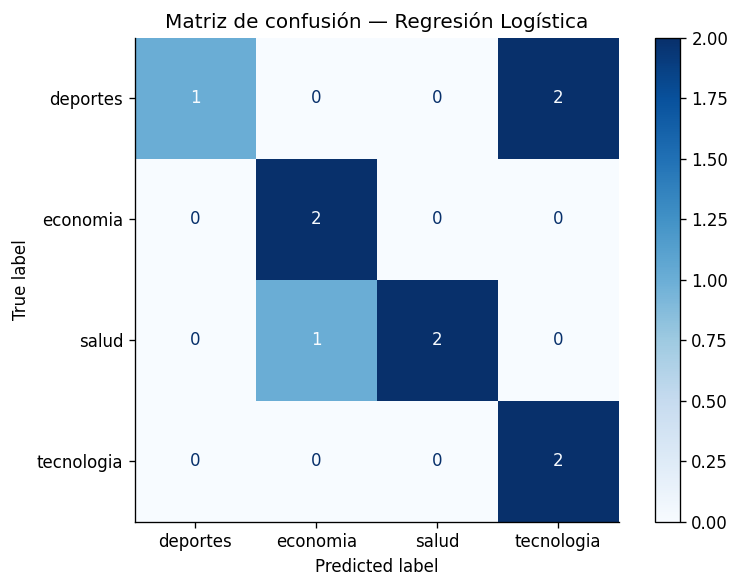

In [ ]:
# Matriz de confusión del mejor modelo
mejor_news = df_res_news.loc[df_res_news["Accuracy"].idxmax(), "Modelo"]
y_pred_news = modelos_news[mejor_news].predict(X_te)

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_te, y_pred_news,
    display_labels=["deportes", "economia", "salud", "tecnologia"],
    cmap="Blues", ax=ax)
ax.set_title(f"Matriz de confusión — {mejor_news}")
plt.tight_layout()
plt.show()

In [ ]:
# Predicción sobre noticias nuevas
nuevas_noticias = [
    "El equipo ganó el campeonato nacional de fútbol en un partido emocionante.",
    "El banco central anunció una subida de tasas para controlar la inflación.",
    "Investigadores desarrollan un nuevo tratamiento para la diabetes tipo dos.",
    "La empresa de tecnología lanzó un nuevo modelo de inteligencia artificial.",
]

pipe_mejor_news = modelos_news[mejor_news]
preds = pipe_mejor_news.predict(nuevas_noticias)

for texto, pred in zip(nuevas_noticias, preds):
    print(f"[{pred.upper():>11}]  {texto[:65]}...")

[   DEPORTES]  El equipo ganó el campeonato nacional de fútbol en un partido emo...
[   ECONOMIA]  El banco central anunció una subida de tasas para controlar la in...
[      SALUD]  Investigadores desarrollan un nuevo tratamiento para la diabetes ...
[ TECNOLOGIA]  La empresa de tecnología lanzó un nuevo modelo de inteligencia ar...


## Sección 9 — Word Embeddings y Visualización t-SNE

Entrenamos un modelo **Word2Vec** sobre el corpus combinado para obtener representaciones vectoriales densas.  
Luego usamos **t-SNE** para proyectar los vectores de alta dimensión a 2D y visualizar la similitud semántica.

### 9.1 — Entrenar Word2Vec

In [ ]:
# Preparar corpus de oraciones tokenizadas (Word2Vec necesita listas de tokens)
corpus_total = pd.concat([df_resenas["texto_limpio"],
                          df_noticias["texto_limpio"]]).reset_index(drop=True)

oraciones = [texto.split() for texto in corpus_total]

# Entrenar Word2Vec
w2v = Word2Vec(
    sentences=oraciones,
    vector_size=100,    # dimensión del embedding
    window=5,           # contexto de 5 palabras a cada lado
    min_count=2,        # ignorar palabras que aparecen menos de 2 veces
    workers=2,
    epochs=50,
    seed=42
)

print(f"Vocabulario: {len(w2v.wv)} palabras")
print(f"Dimensión de cada vector: {w2v.wv.vector_size}")

Vocabulario: 102 palabras
Dimensión de cada vector: 100


In [ ]:
# Extraer las palabras del diccionario
w2v.wv.key_to_index.keys()

dict_keys(['producto', 'nuevo', 'calidad', 'llegar', 'ciento', 'malo', 'tres', 'servicio', 'tras', 'equipo', 'último', 'crecer', 'aunque', 'primero', 'funcionar', 'buen', 'superar', 'precio', 'sector', 'aumento', 'enfermedad', 'internacional', 'récord', 'nacional', 'anunciar', 'permitir', 'detectar', 'empresa', 'médico', 'tiempo', 'cumplir', 'uso', 'comprar', 'entrega', 'cliente', 'compra', 'rápido', 'excelente', 'gasto', 'crecimiento', 'nivel', 'inflación', 'caso', 'especialista', 'paciente', 'riesgo', 'reducir', 'estudio', 'mundial', 'mil', 'diez', 'luego', 'liderar', 'campeonato', 'mundo', 'clasificación', 'partido', 'demanda', 'impulsado', 'social', 'alto', 'desarrollar', 'investigador', 'trimestre', 'red', 'presentar', 'según', 'lenguaje', 'dato', 'modelo', 'algoritmo', 'diagnóstico', 'artificial', 'inteligencia', 'mejor', 'ser', 'poder', 'aceptable', 'mostrar', 'artículo', 'sorpresa', 'problema', 'básico', 'paquete', 'responder', 'completamente', 'descripción', 'tardar', 'segundo

### 9.2 — Consultas semánticas

In [ ]:
# Palabras más similares a un término
for palabra in ["producto", "empresa", "partido", "investigador"]:
    try:
        similares = w2v.wv.most_similar(palabra, topn=4)
        top = ", ".join([f"{w} ({s:.2f})" for w, s in similares])
        print(f"  '{palabra}'  →  {top}")
    except KeyError:
        print(f"  '{palabra}' no está en el vocabulario")

  'producto'  →  alto (0.35), funcionar (0.30), precio (0.28), excelente (0.26)
  'empresa'  →  sector (0.30), según (0.24), paquete (0.23), riesgo (0.22)
  'partido'  →  crecer (0.25), envío (0.24), permitir (0.22), diagnóstico (0.19)
  'investigador'  →  problema (0.36), funcionar (0.34), calidad (0.31), diagnóstico (0.31)


In [ ]:
# Analogía vectorial: calidad - buen + malo ≈ ?
try:
    resultado = w2v.wv.most_similar(
        positive=["calidad", "malo"],
        negative=["buen"],
        topn=3
    )
    print("Analogía: calidad - buen + malo ≈")
    for palabra, score in resultado:
        print(f"  {palabra}: {score:.3f}")
except KeyError as e:
    print(f"Palabra no encontrada: {e}")

Analogía: calidad - buen + malo ≈
  exactamente: 0.311
  condición: 0.285
  alto: 0.259


### 9.3 — Visualización t-SNE

In [ ]:
# Seleccionar palabras representativas de cada dominio
palabras_vis = {
    "tecnologia": ["datos", "modelo", "algoritmo", "software", "aprendizaje",
                   "sistema", "inteligencia", "red"],
    "deportes":   ["equipo", "partido", "jugador", "gol", "campeonato",
                   "entrenador", "victoria", "derrota"],
    "salud":      ["médico", "paciente", "tratamiento", "diagnóstico", "hospital",
                   "vacuna", "enfermedad", "clínico"],
    "economia":   ["precio", "mercado", "inflación", "banco", "inversión",
                   "empresa", "deuda", "economía"],
}

colores_vis = {
    "tecnologia": "#1A4FA0",
    "deportes":   "#15803D",
    "salud":      "#B91C1C",
    "economia":   "#C2810A",
}

vectores, etiquetas, palabras_plot = [], [], []

for categoria, palabras in palabras_vis.items():
    for p in palabras:
        if p in w2v.wv:
            vectores.append(w2v.wv[p])
            etiquetas.append(categoria)
            palabras_plot.append(p)

vectores = np.array(vectores)
print(f"Palabras para visualizar: {len(vectores)}")

Palabras para visualizar: 14


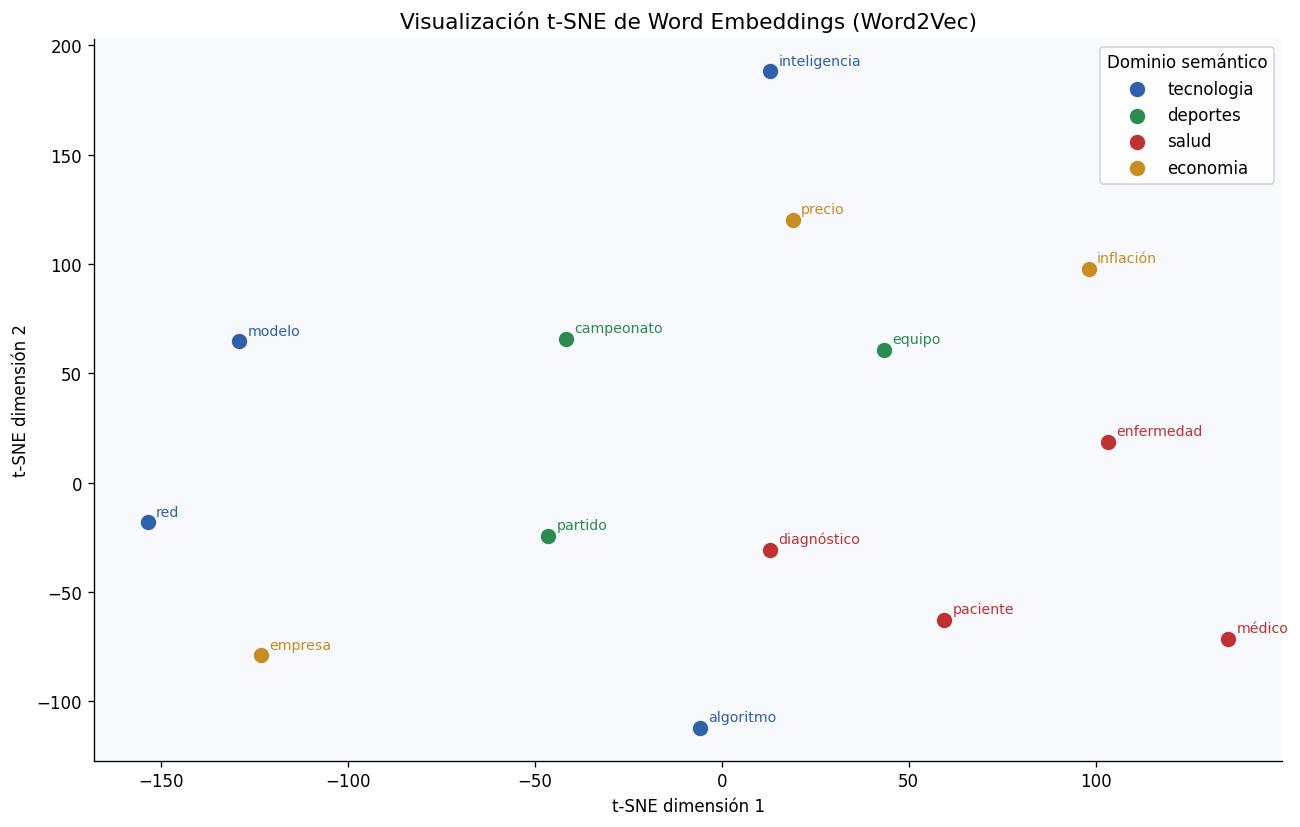

In [ ]:
# Reducción a 2D con t-SNE
tsne = TSNE(n_components=2, perplexity=8, random_state=42,
            max_iter=1000, learning_rate=100)
V_2d = tsne.fit_transform(vectores)

# Graficar
fig, ax = plt.subplots(figsize=(11, 7))
ax.set_facecolor("#F7F9FC")

for cat, color in colores_vis.items():
    idx = [i for i, e in enumerate(etiquetas) if e == cat]
    ax.scatter(V_2d[idx, 0], V_2d[idx, 1],
               c=color, s=100, label=cat,
               edgecolors="white", linewidths=0.8, alpha=0.9)

for i, palabra in enumerate(palabras_plot):
    ax.annotate(palabra, (V_2d[i, 0], V_2d[i, 1]),
                fontsize=8.5, color=colores_vis[etiquetas[i]],
                xytext=(5, 4), textcoords="offset points", alpha=0.9)

ax.legend(title="Dominio semántico", fontsize=10)
ax.set_title("Visualización t-SNE de Word Embeddings (Word2Vec)", fontsize=13)
ax.set_xlabel("t-SNE dimensión 1")
ax.set_ylabel("t-SNE dimensión 2")
plt.tight_layout()
plt.show()

**Interpretación:** palabras semánticamente similares se agrupan en el espacio 2D.  
Idealmente, los cuatro dominios (tecnología, deportes, salud, economía) aparecen como grupos separados.  
El resultado depende del tamaño del corpus — con corpus más grandes los clusters son más nítidos.